# Correlación de señales

Obtener o medir la correlacion significa encontrar semejanzas entre dos señales

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

Creando dos señales de prueba. Es la misma señal con un desplazamiento

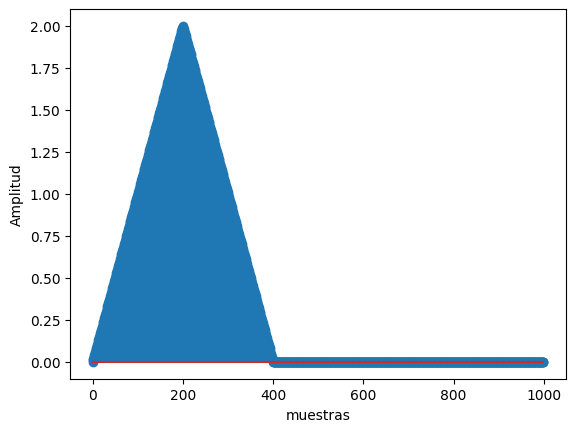

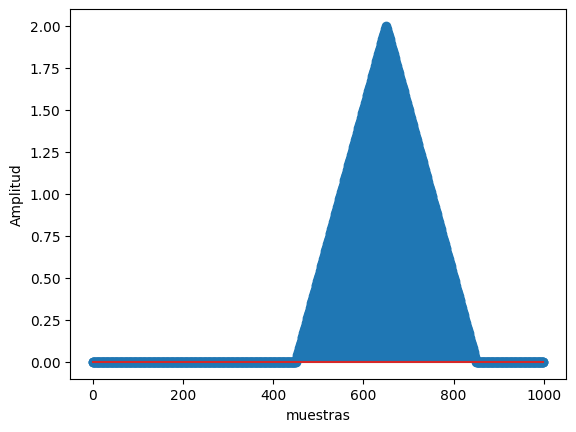

In [10]:
n = np.arange(0,1000)

xn = np.zeros(1000)
xn[0:200] = n[0:200]/100
xn[200:400] = 2-xn[0:200]

yn1 = np.roll(xn, 450)

plt.figure(1)
plt.stem(n,xn)
plt.xlabel("muestras") 
plt.ylabel("Amplitud") 
plt.show()

plt.figure(2)
plt.stem(n,yn1)
plt.xlabel("muestras") 
plt.ylabel("Amplitud") 
plt.show()

Aplicacion de la correlacion cruzada (xn corr yn1) sobre las señales

Text(0.5, 0, 'muestras')

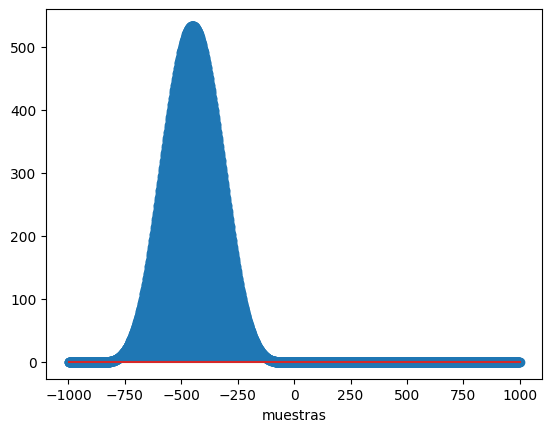

In [11]:
rxy = signal.correlate(xn, yn1)
lags = signal.correlation_lags(xn.size, yn1.size, mode='full')

plt.figure()
plt.stem(lags,rxy)
plt.xlabel('muestras')

Aplicacion de la correlacion cruzada (yn1 corr xn) sobre las señales

Text(0.5, 0, 'muestras')

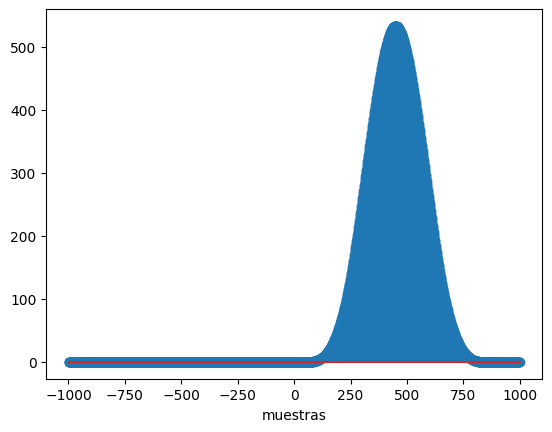

In [12]:
ryx = signal.correlate(yn1, xn)
lags = signal.correlation_lags(xn.size, yn1.size, mode='full')

plt.figure()
plt.stem(lags,ryx)
plt.xlabel('muestras')

Estos resultados demuestran que la correlación cruzada no es una operación conmutativa

## Autocorrelación
La autocorrelacion se calcula entre la señal con ella misma. En este caso xn con xn

Text(0.5, 0, 'muestras')

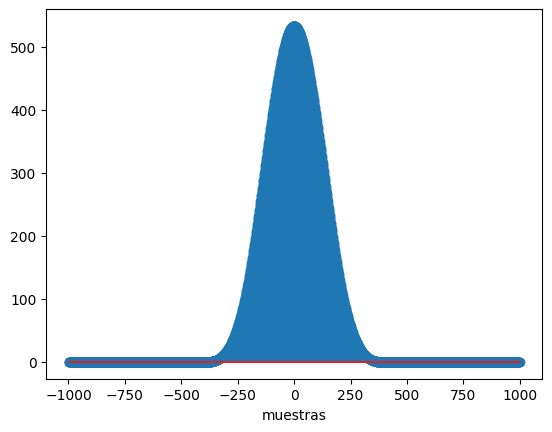

In [13]:
rxx = signal.correlate(xn,xn)
lags = signal.correlation_lags(xn.size, xn.size, mode='full')

plt.figure()
plt.stem(lags,rxx)
plt.xlabel('muestras')

## Normalización
Para eliminar los efectos de escala se puede normalizar el calculo de la correlacion cruzada
Opciones:
* Ninguna
* Sesgada
* Insesgada
* Normalizada

Text(0.5, 0, 'muestras')

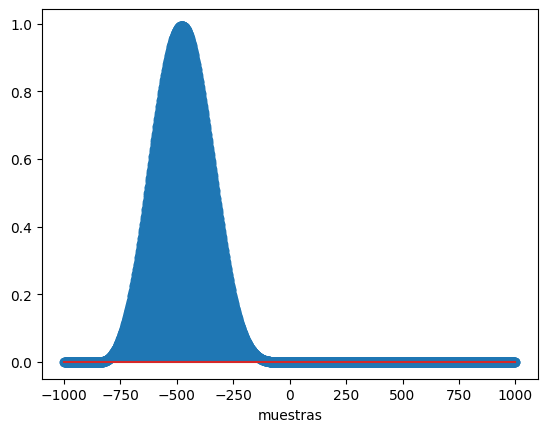

In [17]:
def xcorr_sesgada(xx, yy):
    rxy = signal.correlate(xx,yy)
    lgs = signal.correlation_lags(xx.size,yy.size)
    N = np.size(xx)
    return rxy/N

def xcorr_insesgada(xx, yy):
    rxy = signal.correlate(xx,yy)
    lgs = signal.correlation_lags(xx.size,yy.size)
    N = np.size(xx)
    ks = np.abs(lgs)
    return rxy/(N-ks)

def xcorr_normalized(xx, yy):
    rxy = signal.correlate(xx,yy)
    n_fct = np.linalg.norm(xx) * np.linalg.norm(yy)
    rxy_n = rxy / n_fct
    return rxy_n

rxy_s = xcorr_insesgada(xn, yn1)

plt.figure()
plt.stem(lags,rxy_s)
plt.xlabel('muestras')